In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import random
import editdistance # pip install editdistance

import plotly.graph_objects as go
from IPython.display import display
import shapiq
import matplotlib.pyplot as plt
import math
from collections import defaultdict
import numpy as np
import pandas as pd

In [6]:
%load_ext autoreload
%autoreload 2

In [7]:
from polyseq.modules.utils import is_encoder_decoder, get_next_logits
from polyseq.modules import DecoderOnlyTransformer, RoPEDecoderOnlyTransformer, LSTMSeq2Seq, FullTransformer

### Формулировка задачи и данные

In [51]:
# --- Vocabulary Setup ---
PAD_IDX, SOS_IDX, EOS_IDX, MASK_IDX = 0, 1, 2, 4
# Vocab: PAD, SOS, EOS, 0-9, I, V, X, L, C, D, M, plus a separator for Decoder-only
chars = [
    '<PAD>', '<SOS>', '<EOS>', '<SEP>', '<MASK>',
    '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'I', 'V', 'X', 'L', 'C', 'D', 'M'
]
char2idx = {c: i for i, c in enumerate(chars)}
idx2char = {i: c for i, c in enumerate(chars)}
VOCAB_SIZE = len(chars)


In [39]:
def int_to_roman(num):
    val = [1000, 900, 500, 400, 100, 90, 50, 40, 10, 9, 5, 4, 1]
    syb = ["M", "CM", "D", "CD", "C", "XC", "L", "XL", "X", "IX", "V", "IV", "I"]
    roman_num = ''
    i = 0
    while num > 0:
        for _ in range(num // val[i]):
            roman_num += syb[i]
            num -= val[i]
        i += 1
    return roman_num


def roman_to_int(s):
    """Converts a Roman numeral string to an integer."""
    roman_val = {'I': 1, 'V': 5, 'X': 10, 'L': 50, 'C': 100, 'D': 500, 'M': 1000}
    int_val = 0
    prev_value = 0
    
    # Iterate from right to left
    for char in reversed(s):
        curr_value = roman_val[char]
        # If the current value is less than the previous, it's a subtractive case (e.g., I before V)
        if curr_value < prev_value:
            int_val -= curr_value
        # Otherwise, add it normally
        else:
            int_val += curr_value
        prev_value = curr_value
            
    return int_val


In [52]:
{e: int_to_roman(e) for e in [1, 10, 25, 239]}

{1: 'I', 10: 'X', 25: 'XXV', 239: 'CCXXXIX'}

In [62]:
def generate_batch(batch_size=32, max_len=15, two_sided: bool = False, mask_input: bool = False, mask_output: bool = False):
    """Generates an infinite stream of Arabic -> Roman numeral pairs."""
    mask_input_prob = 0.1
    mask_output_prob = mask_input_prob/2

    while True:
        enc_inputs, dec_inputs, targets = [], [], []
        decoder_only_inputs, decoder_only_targets = [], []

        for _ in range(batch_size):
            num = random.randint(1, 3999)
            # if random.randint(0, 1):
            #     num = random.randint(2000, 3999)
            # else:
            #     num = random.randint(1, 100)
            arabic_str = str(num)
            # arabic_str = str(num).zfill(4)
            roman_str = int_to_roman(num)

            if two_sided:
                if random.randint(0, 1):
                    arabic_str, roman_str = roman_str, arabic_str

            input_tokens = [char2idx[c] for c in arabic_str]
            target_tokens = [char2idx[c] for c in roman_str]

            # Mask only token ids (never inject '<MASK>' into raw strings).
            if mask_input:
                input_tokens = [
                    MASK_IDX if random.random() < mask_input_prob else tok
                    for tok in input_tokens
                ]

            dec_in_tokens = target_tokens
            if mask_output:
                dec_in_tokens = [
                    MASK_IDX if random.random() < mask_output_prob else tok
                    for tok in target_tokens
                ]

            # Encoder-Decoder formats
            enc_seq = input_tokens + [EOS_IDX]
            dec_in_seq = [SOS_IDX] + dec_in_tokens
            target_seq = target_tokens + [EOS_IDX]

            # Decoder-only format (Arabic <SEP> Roman)
            full_seq = enc_seq[:-1] + [char2idx['<SEP>']] + target_seq
            dec_only_in = [SOS_IDX] + full_seq[:-1]
            dec_only_tgt = full_seq

            if mask_output and len(target_tokens) > 0:
                out_start = len(input_tokens) + 2  # [SOS] + input + [SEP]
                for i in range(out_start, len(dec_only_in)):
                    if random.random() < mask_output_prob:
                        dec_only_in[i] = MASK_IDX

            enc_inputs.append(torch.tensor(enc_seq))
            dec_inputs.append(torch.tensor(dec_in_seq))
            targets.append(torch.tensor(target_seq))

            decoder_only_inputs.append(torch.tensor(dec_only_in))
            decoder_only_targets.append(torch.tensor(dec_only_tgt))

        # Pad sequences
        enc_inputs = nn.utils.rnn.pad_sequence(enc_inputs, padding_value=PAD_IDX, batch_first=True)
        dec_inputs = nn.utils.rnn.pad_sequence(dec_inputs, padding_value=PAD_IDX, batch_first=True)
        targets = nn.utils.rnn.pad_sequence(targets, padding_value=PAD_IDX, batch_first=True)

        dec_only_in_padded = nn.utils.rnn.pad_sequence(decoder_only_inputs, padding_value=PAD_IDX, batch_first=True)
        dec_only_tgt_padded = nn.utils.rnn.pad_sequence(decoder_only_targets, padding_value=PAD_IDX, batch_first=True)

        yield enc_inputs, dec_inputs, targets, dec_only_in_padded, dec_only_tgt_padded

In [50]:
for _ in range(1,10):
    enc_inputs, dec_inputs, targets, dec_only_in_padded, dec_only_tgt_padded = next(generate_batch(batch_size=1, max_len=15, two_sided=False, mask_input=True, mask_output=True))

### Метрики

In [54]:
def compute_metrics(pred_tokens, target_tokens):
    """Calculates Levenshtein distance and exact match."""
    pred_str = "".join([idx2char[idx] for idx in pred_tokens if idx not in [PAD_IDX, SOS_IDX, EOS_IDX]])
    tgt_str = "".join([idx2char[idx] for idx in target_tokens if idx not in [PAD_IDX, SOS_IDX, EOS_IDX]])
    
    lev_dist = editdistance.eval(pred_str, tgt_str)
    exact_match = 1 if pred_str == tgt_str else 0
    return lev_dist, exact_match


### Декодирование (генерация)

In [55]:
def generate_numeral(model, input_str, strategy="greedy", beam_width=3, temperature=1.0, max_len=15):
    """
    Translates an Arabic numeral string to Roman using the specified decoding strategy.
    """
    model.eval()
    device = next(model.parameters()).device
    
    # 1. Prepare the Encoder Input
    # if isinstance(model, DecoderOnlyTransformer) or isinstance(model, RoPEDecoderOnlyTransformer):
    if is_encoder_decoder(model):
        # Format: [Arabic] <EOS>
        enc_seq = [char2idx[c] for c in input_str] + [EOS_IDX]
        dec_seq = [SOS_IDX]
    else:
        # Format: [Arabic] <SEP>
        enc_seq = [char2idx[c] for c in input_str] + [char2idx['<SEP>']]
        dec_seq = [SOS_IDX] + enc_seq
        # print('dec_input =', ' '.join([idx2char[c] for c in dec_seq]))
        
    enc_inputs = torch.tensor([enc_seq]).to(device)
    dec_input = torch.tensor([dec_seq]).to(device)
    
    # --- Strategy 1 & 2: Greedy and Sampling ---
    if strategy in ["greedy", "sample"]:
        generated_tokens = []
        lstm_hidden = None
        
        with torch.no_grad():
            for _ in range(max_len):
                logits, lstm_hidden = get_next_logits(model, enc_inputs, dec_input, lstm_hidden)
                
                if strategy == "greedy":
                    next_token = torch.argmax(logits, dim=-1).item()
                else: # sample
                    logits = logits / temperature
                    probs = F.softmax(logits, dim=-1)
                    next_token = torch.distributions.Categorical(probs).sample().item()
                
                if next_token == EOS_IDX:
                    break
                    
                generated_tokens.append(next_token)
                dec_input = torch.cat([dec_input, torch.tensor([[next_token]]).to(device)], dim=1)
                
        return "".join([idx2char[idx] for idx in generated_tokens])

    # --- Strategy 3: Beam Search ---
    elif strategy == "beam":
        # Beams store tuples of: (sequence_tensor, log_probability_score, lstm_hidden_state)
        beams = [(dec_input, 0.0, None)]
        finished_beams = []
        
        with torch.no_grad():
            for _ in range(max_len):
                new_beams = []
                for seq, score, hidden in beams:
                    # If this beam already hit EOS, it shouldn't be here (handled below), 
                    # but safety check:
                    if seq[0, -1].item() == EOS_IDX:
                        continue
                        
                    logits, next_hidden = get_next_logits(model, enc_inputs, seq, hidden)
                    log_probs = F.log_softmax(logits, dim=-1).squeeze(0) # [VOCAB_SIZE]
                    
                    # Get top 'beam_width' candidates for THIS specific beam
                    topk_log_probs, topk_indices = torch.topk(log_probs, beam_width)
                    
                    for i in range(beam_width):
                        next_tok = topk_indices[i].unsqueeze(0).unsqueeze(0)
                        new_seq = torch.cat([seq, next_tok], dim=1)
                        new_score = score + topk_log_probs[i].item()
                        
                        if next_tok.item() == EOS_IDX:
                            # If we hit EOS, save to finished beams and don't expand further
                            finished_beams.append((new_seq, new_score))
                        else:
                            new_beams.append((new_seq, new_score, next_hidden))
                
                # Sort all newly expanded beams by score (descending) and keep top 'beam_width'
                new_beams = sorted(new_beams, key=lambda x: x[1], reverse=True)[:beam_width]
                beams = new_beams
                
                # Early stopping: if we have enough finished beams that are better than active ones
                if len(finished_beams) >= beam_width:
                    break
                    
        # Combine finished and any remaining active beams, then pick the absolute best
        all_candidates = finished_beams + [(b[0], b[1]) for b in beams]
        best_seq_tensor = sorted(all_candidates, key=lambda x: x[1], reverse=True)[0][0]
        
        # Convert tensor to string (ignoring SOS and EOS)
        token_list = best_seq_tensor.squeeze().tolist()
        clean_tokens = [tok for tok in token_list if tok not in (SOS_IDX, EOS_IDX)]
        return "".join([idx2char[idx] for idx in clean_tokens]).split("<SEP>")[-1]

    else:
        raise ValueError("Strategy must be 'greedy', 'sample', or 'beam'")


### Обучение

In [71]:
def train_supervised_live(model, steps=2000, val_freq=100, val_steps=10,
                          lr=1e-3, weight_decay=0.01, mask_input=False, mask_output=False):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = torch.nn.CrossEntropyLoss(ignore_index=PAD_IDX)
    
    train_gen = generate_batch(batch_size=32, mask_input=mask_input, mask_output=mask_output)
    val_gen = generate_batch(batch_size=32,  mask_input=mask_input, mask_output=mask_output) 
    
    history = defaultdict(list)
    
    # --- 1. Initialize the FigureWidget ONCE ---
    fig = go.FigureWidget(layout=go.Layout(
        title="Training Progress",
        xaxis_title="Training Steps",
        yaxis_title="Metrics",
        template="plotly_white"
    ))
    
    # Add empty traces for our metrics
    fig.add_scatter(x=[], y=[], mode='lines', name='Train Loss', line=dict(color='blue'))
    fig.add_scatter(x=[], y=[], mode='lines', name='Val Loss', line=dict(color='orange'))
    # fig.add_scatter(x=[], y=[], mode='lines', name='Val Exact Match', line=dict(color='green'))
    
    # Display the empty widget initially
    display(fig)
    
    for step in range(1, steps + 1):
        model.train()
        enc_inputs, dec_inputs, targets, dec_only_in, dec_only_tgt = next(train_gen)
        optimizer.zero_grad()
        
        if is_encoder_decoder(model):
            logits = model(enc_inputs, dec_inputs)
            loss = criterion(logits.reshape(-1, VOCAB_SIZE), targets.reshape(-1))
        else:
            # Find <SEP> positions
            sep_mask = (dec_only_in == char2idx['<SEP>'])
            # Create a mask for tokens AFTER <SEP>
            after_sep_mask = sep_mask.cumsum(dim=1) > 0
            # Shift mask to align with targets
            loss_mask = after_sep_mask
            targets_flat = dec_only_tgt.reshape(-1)
            mask_flat = loss_mask.reshape(-1)
            valid_mask = mask_flat & (targets_flat != PAD_IDX)
            logits = model(dec_only_in)
            loss = criterion(logits.reshape(-1, VOCAB_SIZE)[valid_mask], targets_flat[valid_mask])
            
        loss.backward()
        optimizer.step()
        
        # --- Validation & Plot Updating Phase ---
        if step % val_freq == 0:
            model.eval()
            val_loss_total, val_lev_total, val_em_total = 0, 0, 0
            
            with torch.no_grad():
                for _ in range(val_steps):
                    v_enc_in, v_dec_in, v_targets, v_dec_only_in, v_dec_only_tgt = next(val_gen)
                    
                    if is_encoder_decoder(model):
                        v_logits = model(v_enc_in, v_dec_in)
                        v_loss = criterion(v_logits.reshape(-1, VOCAB_SIZE), v_targets.reshape(-1))
                        preds = torch.argmax(v_logits, dim=-1)
                        actual_targets = v_targets
                    else:
                        # Find <SEP> positions
                        sep_mask = (v_dec_only_in == char2idx['<SEP>'])
                        # Create a mask for tokens AFTER <SEP>
                        after_sep_mask = sep_mask.cumsum(dim=1) > 0
                        # Shift mask to align with targets
                        loss_mask = after_sep_mask
                        targets_flat = v_dec_only_tgt.reshape(-1)
                        mask_flat = loss_mask.reshape(-1)
                        valid_mask = mask_flat & (targets_flat != PAD_IDX)
                        
                        v_logits = model(v_dec_only_in)
                        v_loss = criterion(v_logits.reshape(-1, VOCAB_SIZE)[valid_mask], targets_flat[valid_mask])
                        preds = torch.argmax(v_logits, dim=-1)
                        actual_targets = v_dec_only_tgt
                        
                    val_loss_total += v_loss.item()
                    
                    batch_lev, batch_em = 0, 0
                    for i in range(preds.size(0)):
                        lev, em = compute_metrics(preds[i].tolist(), actual_targets[i].tolist())
                        batch_lev += lev
                        batch_em += em
                    
                    val_lev_total += batch_lev / preds.size(0)
                    val_em_total += batch_em / preds.size(0)
                    
            # Update history dictionary
            history['step'].append(step)
            history['train_loss'].append(loss.item())
            history['val_loss'].append(val_loss_total / val_steps)
            history['val_lev_dist'].append(val_lev_total / val_steps)
            history['val_exact_match'].append(val_em_total / val_steps)
            
            # --- 2. Dynamically Update the Existing Traces ---
            with fig.batch_update():
                # Trace 0 is Train Loss
                fig.data[0].x = history['step']
                fig.data[0].y = history['train_loss']
                # Trace 1 is Val Loss
                fig.data[1].x = history['step']
                fig.data[1].y = history['val_loss']
                # Trace 2 is Val Exact Match
                # fig.data[2].x = history['step']
                # fig.data[2].y = history['val_exact_match']
                
                # Update the title dynamically
                fig.layout.title.text = f"Training Progress (Step {step}/{steps})"

    return history

Пример последовательностей на входе и выходе:

In [63]:
gen = generate_batch(batch_size=32,mask_input=True, mask_output=True)
enc_inputs, dec_inputs, targets, dec_only_in, dec_only_tgt = next(iter(gen))

In [64]:
''.join([idx2char[c] for c in dec_only_in[0].tolist()])

'<SOS>2736<SEP>MMDC<MASK>XXXVI<PAD>'

In [65]:
''.join([idx2char[c] for c in dec_only_tgt[0].tolist()])

'2736<SEP>MMDCCXXXVI<EOS><PAD>'

Здесь очевидно, что не надо пытаться предсказывать токены до `<SEP>`, так как это входная информация.

In [73]:
# model = LSTMSeq2Seq(VOCAB_SIZE)
# model = FullTransformer(vocab_size=VOCAB_SIZE, num_layers=2)
# model = DecoderOnlyTransformer(vocab_size=VOCAB_SIZE, num_layers=4)
model = RoPEDecoderOnlyTransformer(vocab_size=VOCAB_SIZE, nhead=8, d_model=64, num_layers=3, pad_idx=PAD_IDX)

history = train_supervised_live(
    model,
    steps=3000,
    # steps=500,
    val_freq=100,
    val_steps=10,
    lr=1.e-4,
    weight_decay=1e-4,
    mask_input=True,
    mask_output=False
)

FigureWidget({
    'data': [{'line': {'color': 'blue'},
              'mode': 'lines',
              'name': 'Train Loss',
              'type': 'scatter',
              'uid': '2e26358f-4418-4362-8e27-847d63b6869a',
              'x': [],
              'y': []},
             {'line': {'color': 'orange'},
              'mode': 'lines',
              'name': 'Val Loss',
              'type': 'scatter',
              'uid': 'b04c6b66-4683-4db5-8ce4-befea48ec014',
              'x': [],
              'y': []}],
    'layout': {'template': '...',
               'title': {'text': 'Training Progress'},
               'xaxis': {'title': {'text': 'Training Steps'}},
               'yaxis': {'title': {'text': 'Metrics'}}}
})

In [67]:
torch.save(model, 'model.pt')

In [74]:
test_numbers = ["1", "4", "9", "58", "39", "239", "1984", "3999"]

res = defaultdict(list)
for num in test_numbers:
    try:
        target = int_to_roman(int(num))
    except:
        target = int(roman_to_int(num))
    greedy_res = generate_numeral(model, num, strategy="greedy")
    sample_res = generate_numeral(model, num, strategy="sample", temperature=1.e-10)
    beam_res   = generate_numeral(model, num, strategy="beam", beam_width=3)

    res['Input'].append(num)
    res['Target'].append(target)
    res['Greedy'].append(greedy_res)
    res['Sample'].append(sample_res)
    res['Beam'].append(beam_res)

res = pd.DataFrame(res)
res

,Input,Target,Greedy,Sample,Beam
0,1,I,I,I,I
1,4,IV,IV,IV,IV
2,9,IX,IX,IX,IX
3,58,LVIII,LVIII,LVIII,LVIII
4,39,XXXIX,XCIII,XCIII,XCIII
5,239,CCXXXIX,CCXXXIX,CCXXXIX,CCXXXIX
6,1984,MCMLXXXIV,MCMLXXXIV,MCMLXXXIV,MCMLXXXI
7,3999,MMMCMXCIX,MMMCMXCIX,MMMCMXCIX,MMMCMXCI


### Интерпретация предсказаний

In [78]:
class NumeralExplainerWrapper:
    def __init__(self, model, input_str, generated_prefix, target_char, features=None):
        """
        Args:
            model: The trained DecoderOnlyTransformer.
            input_str (str): The Arabic numeral input (e.g., "19").
            generated_prefix (list): Token IDs generated so far (e.g., [char2idx['X']]).
            target_char (str): The character we want to explain the prediction for (e.g., "I").
            features (list[str] | None): Fragment-level features. If None, falls back to per-character features.
        """
        self.model = model.eval()
        self.input_str = input_str
        self.input_chars = list(input_str)
        self.generated_prefix = generated_prefix
        self.target_idx = char2idx[target_char]
        self.device = next(model.parameters()).device

        if features is None:
            self.features = list(input_str)
        else:
            self.features = list(features)

        if "".join(self.features) != input_str:
            raise ValueError("features must form an ordered partition of input_str")

        self.feature_to_positions = {}
        cursor = 0
        for feature_idx, fragment in enumerate(self.features):
            fragment_len = len(fragment)
            positions = list(range(cursor, cursor + fragment_len))
            self.feature_to_positions[feature_idx] = positions
            cursor += fragment_len

        self.base_input_token_ids = [char2idx[ch] for ch in self.input_chars]
        self.n_features = len(self.features)

    def __call__(self, coalitions):
        """
        Evaluates the model on a batch of binary feature masks.
        coalitions: numpy array of shape (n_samples, n_features) of booleans.
        """
        results = []
        for coalition in coalitions:
            token_ids = self.base_input_token_ids.copy()

            # Interpret coalition over fragment features.
            for feature_idx, is_present in enumerate(coalition):
                if not is_present:
                    for token_pos in self.feature_to_positions[feature_idx]:
                        token_ids[token_pos] = MASK_IDX

            # 2. Construct sequence: [SOS] [Masked Arabic] <SEP> [Prefix]
            enc_seq = [SOS_IDX] + token_ids + [char2idx['<SEP>']]
            full_seq = enc_seq + self.generated_prefix

            model_input = torch.tensor([full_seq]).to(self.device)

            # 3. Get logit for the target token at the very last step
            with torch.no_grad():
                logits = self.model(model_input)
                target_logit = logits[0, -1, self.target_idx].item()
                results.append(target_logit)

        return np.array(results)

In [79]:
def explain_and_plot_sentence(model, input_str="19", target_char="I", prefix_chars=['X'], features=None, plot=True):
    """
    Computes shapiq interactions and visualizes them using a sentence plot.

    Args:
        features (list[str] | None): Optional ordered fragments over input_str.
            Example for "239": ["2", "39"] or ["23", "9"].
    """
    prefix_tokens = [char2idx[c] for c in prefix_chars]

    wrapper = NumeralExplainerWrapper(
        model=model,
        input_str=input_str,
        generated_prefix=prefix_tokens,
        target_char=target_char,
        features=features,
    )

    computer = shapiq.AgnosticExplainer(
        wrapper,
        index='k-SII',
        # index='SV',
        n_players=wrapper.n_features,
        max_order=wrapper.n_features,
        approximator='svarm'
    )
    interaction_values = computer.explain(budget=128)
    words = wrapper.features
    print(f"Explaining prediction of '{target_char}' after prefix '{''.join(prefix_chars)}' for input '{input_str}'")

    if plot:
        fig, ax = shapiq.plot.sentence_plot(
            interaction_values=interaction_values,
            words=words,
            show=False # We handle showing it manually below
        )

        plt.show()
    return dict(interaction_values=interaction_values, words=words, feature_to_positions=wrapper.feature_to_positions)


Explaining prediction of 'X' after prefix 'CCXXXI' for input '239'


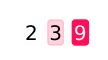

In [80]:
explain_and_plot_sentence(model, input_str="239", target_char="X", prefix_chars=list('CCXXXI'));

Explaining prediction of 'I' after prefix 'XX' for input '20'


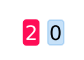

In [20]:
explain_and_plot_sentence(model, input_str="20", target_char="I", prefix_chars=list('XX'));

Explaining prediction of 'X' after prefix 'XX' for input '30'


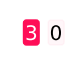

In [21]:
explain_and_plot_sentence(model, input_str="30", target_char="X", prefix_chars=list('XX'));

Explaining prediction of 'V' after prefix 'MCCXXXI' for input '1234'


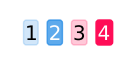

In [22]:
explain_and_plot_sentence(model, input_str="1234", target_char="V", prefix_chars=list('MCCXXXI'));

Explaining prediction of 'V' after prefix 'MCCXXXI' for input '1234'


c:\Users\krellQ\AppData\Local\Programs\Python\Python310\lib\site-packages\shapiq\approximator\montecarlo\base.py:107: UserWarning:

Not all budget is required due to the border-trick.



(<Figure size 700x700 with 1 Axes>, <Axes: >)

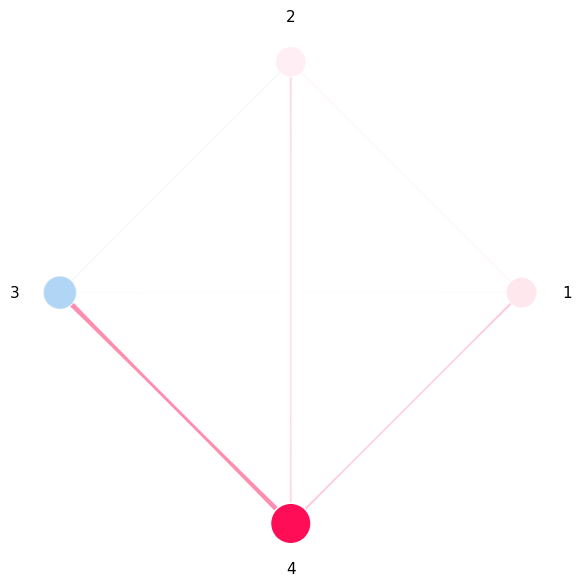

In [94]:
res = explain_and_plot_sentence(model, input_str="1234", target_char="V", prefix_chars=list('MCCXXXI'), plot=False)
shapiq.plot.network_plot(
    interaction_values=res['interaction_values'],
    feature_names=res['words'],
    show=False # We handle showing it manually below
)

In [82]:
res

{'interaction_values': InteractionValues(
     index=k-SII, max_order=4, min_order=0, estimated=False, estimation_budget=128,
     n_players=4, baseline_value=3.6754188537597656
 ),
 'words': ['1', '2', '3', '4'],
 'feature_to_positions': {0: [0], 1: [1], 2: [2], 3: [3]}}

Explaining prediction of 'V' after prefix 'MCCXXXI' for input '1234'


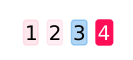

{0: [0], 1: [1], 2: [2], 3: [3]}


In [83]:
res = explain_and_plot_sentence(
    model,
    input_str="1234",
    target_char="V",
    prefix_chars=list("MCCXXXI"),
    features=["1","2","3","4"],
    plot=True
)
print(res["feature_to_positions"])

Explaining prediction of 'V' after prefix 'MCCXXXI' for input '1234'


c:\Users\krellQ\AppData\Local\Programs\Python\Python310\lib\site-packages\shapiq\approximator\montecarlo\base.py:107: UserWarning:

Not all budget is required due to the border-trick.



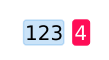

{0: [0, 1, 2], 1: [3]}


In [84]:
res = explain_and_plot_sentence(
    model,
    input_str="1234",
    target_char="V",
    prefix_chars=list("MCCXXXI"),
    features=["123", "4"],
    plot=True
)
print(res["feature_to_positions"])

## Задание со 🌟

In [ ]:
import math
import numpy as np
import torch
import torch.nn.functional as F

class PerplexityExplainerWrapper:

    def __init__(self, model, input_str, candidate_output_str, include_eos=True):
        self.model = model.eval()
        self.device = next(model.parameters()).device

        self.input_str = input_str
        self.candidate_output_str = candidate_output_str

        self.input_token_ids = [char2idx[c] for c in list(input_str)]
        self.candidate_token_ids = [char2idx[c] for c in list(candidate_output_str)]
        if include_eos:
            self.candidate_token_ids = self.candidate_token_ids + [EOS_IDX]

        self.words = [idx2char[t] for t in self.candidate_token_ids]  # labels for sentence plot
        self.n_features = len(self.candidate_token_ids)
        self.feature_to_positions = {i: [i] for i in range(self.n_features)}

        self.prefix_ids = [SOS_IDX] + self.input_token_ids + [char2idx["<SEP>"]]
        full_ids = self.prefix_ids + self.candidate_token_ids

        model_input = torch.tensor([full_ids[:-1]], dtype=torch.long, device=self.device)
        targets = torch.tensor(full_ids[1:], dtype=torch.long, device=self.device)

        with torch.no_grad():
            logits = self.model(model_input)                     # [1, T, V]
            log_probs = F.log_softmax(logits[0], dim=-1)        # [T, V]

        cand_start = len(self.prefix_ids) - 1
        cand_len = len(self.candidate_token_ids)

        self.nll_per_pos = []
        for i in range(cand_len):
            t_idx = cand_start + i
            tok = targets[t_idx].item()
            nll = -log_probs[t_idx, tok].item()
            self.nll_per_pos.append(nll)

        self.nll_per_pos = np.array(self.nll_per_pos, dtype=np.float64)

        self.base_mean_nll = float(self.nll_per_pos.mean())
        self.base_perplexity = float(math.exp(self.base_mean_nll))
        self.base_score = -self.base_perplexity

    def __call__(self, coalitions):
        coalitions = np.asarray(coalitions).astype(bool)
        results = []
        for mask in coalitions:
            selected = self.nll_per_pos[mask]
            if selected.size == 0:
                # Empty coalition: neutral fallback
                results.append(0.0)
                continue
            mean_nll = float(selected.mean())
            ppl = float(math.exp(mean_nll))
            results.append(-ppl)
        return np.array(results, dtype=np.float64)

In [ ]:
def explain_sequence_perplexity(
    model,
    input_str="11",
    candidate_output_str="XI",
    budget=256,
    plot=True,
):

    wrapper = PerplexityExplainerWrapper(
        model=model,
        input_str=input_str,
        candidate_output_str=candidate_output_str,
        include_eos=True,
    )

    explainer = shapiq.AgnosticExplainer(
        wrapper,
        index="k-SII",          
        n_players=wrapper.n_features,
        max_order=wrapper.n_features,
        approximator="svarm",
    )
    interaction_values = explainer.explain(budget=budget)

    print(f"Input: {input_str}")
    print(f"Candidate output: {candidate_output_str}<EOS>")
    print(f"Baseline perplexity (all positions): {wrapper.base_perplexity:.4f}")

    if plot:
        fig, ax = shapiq.plot.sentence_plot(
            interaction_values=interaction_values,
            words=wrapper.words,
            show=False
        )
        plt.show()

    return {
        "interaction_values": interaction_values,
        "words": wrapper.words,
        "feature_to_positions": wrapper.feature_to_positions,
        "base_perplexity": wrapper.base_perplexity,
        "nll_per_pos": wrapper.nll_per_pos,
    }

Input: 11
Candidate output: XI<EOS>
Baseline perplexity (all positions): 1.0667


c:\Users\krellQ\AppData\Local\Programs\Python\Python310\lib\site-packages\shapiq\approximator\montecarlo\base.py:107: UserWarning:

Not all budget is required due to the border-trick.



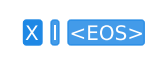

In [87]:
res = explain_sequence_perplexity(model, input_str="11", candidate_output_str="XI", budget=256, plot=True)

In [88]:
for i, (w, nll) in enumerate(zip(res["words"], res["nll_per_pos"])):
    print(f"  pos={i:2d}, token={w:>5s}, NLL={nll:.4f}")


  pos= 0, token=    X, NLL=0.1854
  pos= 1, token=    I, NLL=0.0052
  pos= 2, token=<EOS>, NLL=0.0031


Input: 11
Candidate output: XX<EOS>
Baseline perplexity (all positions): 73.7360


c:\Users\krellQ\AppData\Local\Programs\Python\Python310\lib\site-packages\shapiq\approximator\montecarlo\base.py:107: UserWarning:

Not all budget is required due to the border-trick.



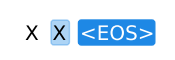

In [89]:
res_bad = explain_sequence_perplexity(model, input_str="11", candidate_output_str="XX", budget=256,plot=True)

In [93]:
for i, (w, nll) in enumerate(zip(res_bad["words"], res_bad["nll_per_pos"])):
    print(f"  pos={i:2d}, token={w:>5s}, NLL={nll:.4f}")
bad_pos = int(np.argmax(res_bad["nll_per_pos"]))
print(f"wrong pos:{bad_pos}")

  pos= 0, token=    X, NLL=0.1854
  pos= 1, token=    X, NLL=5.8456
  pos= 2, token=<EOS>, NLL=6.8705
wrong pos:2
